<a href="https://colab.research.google.com/github/jaredGtzC/LAB_PDI/blob/main/Practica_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 5.- Tipos de Traslaciones de Imágenes.

* Olga Regina Charles Moreno          - 2049291
* David Aldebarán Cardona Padilla     - 2043428
* Jared Gutiérrez Contreras           - 2131945


**Parte I.- Transformaciones Geometricas**


## EJERCICIO 1. Traslación básica de imagen

Para comenzar con las transformaciones geométricas, se seleccionó una imagen médica en escala de grises de una resonancia magnetica del torax

Para el desarrollo del ejercicio se emplean las librerías OpenCV, NumPy y Matplotlib, las cuales permiten cargar, procesar y visualizar imágenes dentro del entorno de Python.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Posteriormente, se carga la imagen utilizando la función `cv2.imread()`, indicando que se lea en escala de grises. Además, se obtienen sus dimensiones mediante `.shape`, lo cual es necesario para mantener el tamaño original durante las transformaciones.

(np.float64(-0.5), np.float64(1791.5), np.float64(1023.5), np.float64(-0.5))

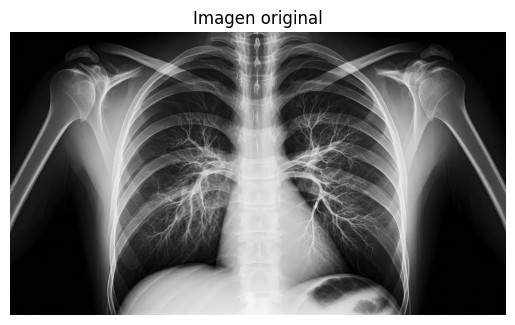

In [12]:
imagen = cv2.imread("RMT.jpg", cv2.IMREAD_GRAYSCALE)
alto, ancho = imagen.shape

plt.imshow(imagen, cmap="gray")
plt.title("Imagen original")
plt.axis("off")

Luego se realiza una traslación de la imagen, desplazando todos sus píxeles 50 unidades en el eje horizontal (x) y 30 unidades en el eje vertical (y). Este tipo de transformación permite cambiar la posición de la imagen sin modificar su forma ni su tamaño.

In [5]:
tx = 50
ty = 30

M = np.float32([[1, 0, tx],
                [0, 1, ty]])

imagen_trasladada = cv2.warpAffine(imagen, M, (ancho, alto))

Esta es una matriz de traslación, en la cual los valores de la diagonal permanecen en 1 para evitar cambios en la escala. Los valores tx y ty indican el desplazamiento en cada eje.

La función `cv2.warpAffine()` aplica la transformación a la imagen utilizando dicha matriz, conservando las dimensiones originales especificadas.

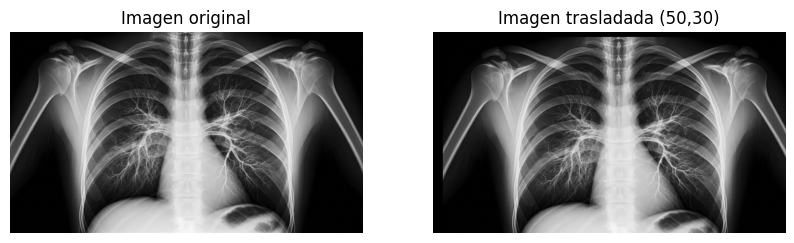

In [6]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(imagen, cmap="gray")
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(imagen_trasladada, cmap="gray")
plt.title("Imagen trasladada (50,30)")
plt.axis("off")

plt.show()

## EJERCICIO 2. Traslación con valores decimales

En este ejercicio se utiliza la misma imagen, pero ahora se aplicará una traslación con valores fraccionarios. Esto implica que los píxeles no se desplazan exactamente a posiciones enteras, lo que requiere el uso de interpolación.

Se emplean desplazamientos de 20.5 en el eje x y 15.5 en el eje y.

In [7]:
tx = 20.5
ty = 15.5

M = np.float32([[1, 0, tx],
                [0, 1, ty]])

imagen_decimal = cv2.warpAffine(imagen, M, (ancho, alto), flags=cv2.INTER_LINEAR)

Debido a que los desplazamientos incluyen valores decimales, se utiliza interpolación lineal (`cv2.INTER_LINEAR`) para estimar los nuevos valores de los píxeles. Esto permite obtener una transición más suave en la imagen resultante.

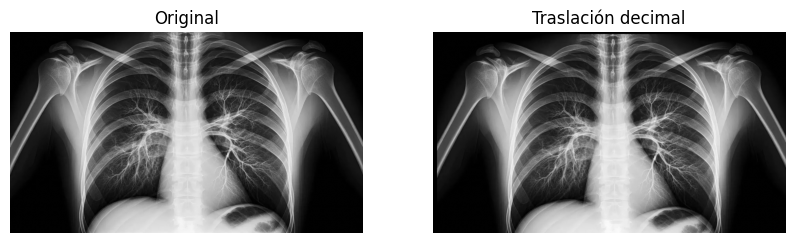

In [8]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(imagen, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(imagen_decimal, cmap="gray")
plt.title("Traslación decimal")
plt.axis("off")

plt.show()

## EJERCICIO 3. Traslación + Rotación

En este caso se combinan dos transformaciones: primero una traslación y posteriormente una rotación. Esto permite observar cómo cambian tanto la posición como la orientación de la imagen.

In [14]:
# Traslación
tx, ty = 40, 25
M_t = np.float32([[1, 0, tx],
                  [0, 1, ty]])

img_t = cv2.warpAffine(imagen, M_t, (ancho, alto))

# Rotación
angulo = 60
centro = (ancho//2, alto//2)

M_r = cv2.getRotationMatrix2D(centro, angulo, 1)
img_tr = cv2.warpAffine(img_t, M_r, (ancho, alto))

La función `cv2.getRotationMatrix2D()` genera la matriz de rotación considerando el centro de la imagen, el ángulo y un factor de escala (en este caso igual a 1).

Posteriormente, se aplica la rotación sobre la imagen previamente trasladada, permitiendo observar el efecto combinado de ambas transformaciones.

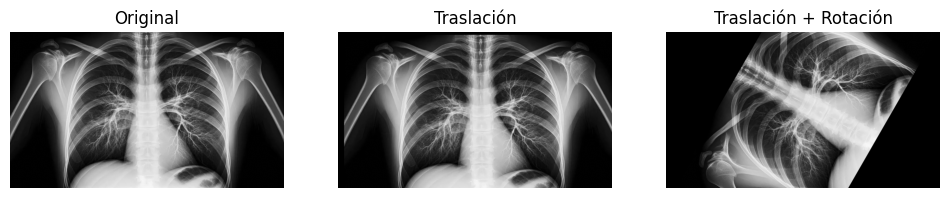

In [15]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(imagen, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(img_t, cmap="gray")
plt.title("Traslación")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(img_tr, cmap="gray")
plt.title("Traslación + Rotación")
plt.axis("off")

plt.show()

## Ejercicio 4. Traslación + Rotación + Escalado

En este ejercicio se añade el escalado a las transformaciones anteriores. El escalado permite modificar el tamaño de la imagen.

Se utilizan dos factores: uno menor a 1 (0.7), que reduce la imagen, y otro mayor a 1 (1.3), que la amplía.

In [10]:
escala1 = 0.8
escala2 = 1.5

M1 = cv2.getRotationMatrix2D(centro, 45, escala1)
M2 = cv2.getRotationMatrix2D(centro, 45, escala2)

img1 = cv2.warpAffine(img_t, M1, (ancho, alto))
img2 = cv2.warpAffine(img_t, M2, (ancho, alto))

Ambas transformaciones se aplican sobre la imagen trasladada, lo que permite observar cómo cambia el tamaño manteniendo la rotación.

El escalado menor permite visualizar más contenido de la imagen, mientras que el escalado mayor enfatiza detalles específicos.

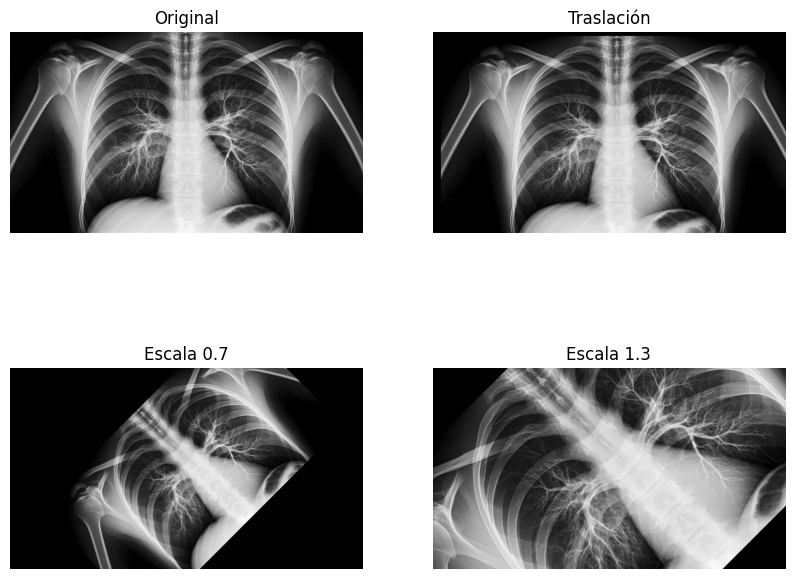

In [16]:
plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.imshow(imagen, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(img_t, cmap="gray")
plt.title("Traslación")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(img1, cmap="gray")
plt.title("Escala 0.7")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(img2, cmap="gray")
plt.title("Escala 1.3")
plt.axis("off")

plt.show()

## Ejercicio 5. Transformación Afín y Radial

En este ejercicio se aplican transformaciones más avanzadas.

La transformación afín permite modificar la geometría de la imagen mediante la definición de puntos de referencia. A partir de estos puntos se genera una matriz que deforma la imagen.

Por otro lado, la distorsión radial modela deformaciones producidas por lentes, como el efecto de ojo de pez.

In [17]:
# Afín
pts1 = np.float32([[50,50],[200,50],[50,200]])
pts2 = np.float32([[10,100],[200,50],[100,250]])

M = cv2.getAffineTransform(pts1, pts2)
img_afin = cv2.warpAffine(imagen, M, (ancho, alto))

La transformación afín se calcula a partir de puntos originales y puntos destino, permitiendo generar deformaciones controladas en la imagen.

In [18]:
# Radial
K = np.array([[1000,0,640],[0,1000,360],[0,0,1]])
dist = np.array([-0.2,0.05,0,0,0])

h, w = imagen.shape
new_K, _ = cv2.getOptimalNewCameraMatrix(K, dist, (w,h), 1, (w,h))

img_radial = cv2.undistort(imagen, K, dist, None, new_K)

La corrección radial ajusta la deformación de la imagen causada por el lente, permitiendo obtener una representación más fiel de las estructuras.

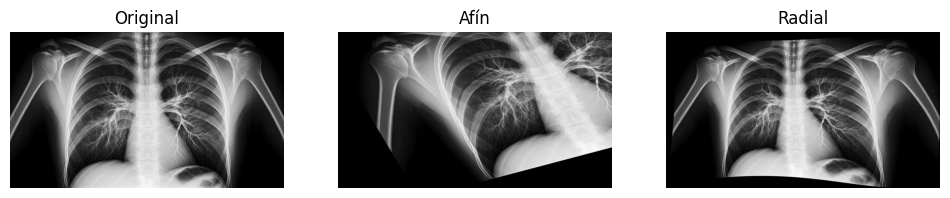

In [19]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(imagen, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(img_afin, cmap="gray")
plt.title("Afín")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(img_radial, cmap="gray")
plt.title("Radial")
plt.axis("off")

plt.show()